
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 5
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consigna

En el repositorio PDStestbench encontrará tres tipos de señales registradas:

- **Electrocardiograma (ECG).** En el archivo ECG_TP4.mat encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
- **Pletismografía (PPG).** El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
- **Audio.** Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.
Los detalles de cómo acceder a dichos registros los pueden encontrar en lectura_sigs.py

Se pide:

**1)** Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

**2)** Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

Bonus:

💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.


# Resolución 

A lo largo de este trabajo se estudió el comportamiento en frecuencia de tres tipos de señales: biomédicas (ECG y PPG) y de audio, con el objetivo de estudiar sus espectros y estimar su ancho de banda útil.

Para calcular la Densidad Espectral de Potencia (PSD), se utilizó el método de Welch en lugar de usar un periodograma común. La ventaja clave de Welch es que logra un excelente equilibrio entre resolución y ruido (varianza). Al dividir la señal en segmentos que se solapan, aplicarles una ventana y promediar los resultados, se logra limpiar el gráfico de ruidos falsos. Esto es fundamental para identificar los picos de frecuencia reales de cada señal.

Para automatizar el procesamiento y mantener el código limpio y ordenado, se utilizó la función *analizar_senal_spectrograma*. Esta función centraliza todo el trabajo en un solo bloque: calcula la PSD con scipy.signal, convierte los valores a escala logarítmica ($\text{dB}$), la grafica y calcula de forma automática el Ancho de Banda al 99% de la potencia. A partir de esta herramienta, el análisis se centró en probar cómo cambia el gráfico según el tamaño de la ventana elegida (nperseg), buscando el punto justo entre el nivel de detalle y la estabilidad para cada señal.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

def analizar_senal_spectrograma(signal, fs, nperseg, titulo="Señal", color='blue', ax=None):
    
    """
    Calcula la PSD usando el método de Welch, estima el ancho de banda al 99% de potencia,
    y grafica el espectro en escala logarítmica (dB).
    
    Parámetros:
    - signal: vector de datos de la señal (numpy array).
    - fs: frecuencia de muestreo en Hz.
    - nperseg: tamaño de la ventana (potencia de 2).
    - titulo: nombre de la señal.
    - color: color del grafico
    - ax: para graficar más de un PSD por grafico
            Si ax=0, no genera ningún gráfico.
    """
    
    # 1. Calcular la PSD con Welch
    f, Pxx_den = sig.welch(signal, fs=fs, nperseg=nperseg)
    
    # 2. Calcular el Ancho de Banda al 99% de la potencia
    potencia_total = np.sum(Pxx_den)
    potencia_acumulada = np.cumsum(Pxx_den)
    indice_99 = np.where(potencia_acumulada >= 0.99 * potencia_total)[0][0]
    ancho_banda_99 = f[indice_99]
    
    # 3. Convertir la PSD a escala logarítmica (dB) para graficar
    Pxx_den_log = 10 * np.log10(Pxx_den)
    
    # 4. Configurar y mostrar el gráfico
    if ax == 0:
        pass  # No genera ningún gráfico
    elif ax is None:
        plt.figure(figsize=(14, 6))
        plt.plot(f, Pxx_den_log, linewidth=1.5, label='PSD', color=color)
        plt.title(f"PSD de {titulo} (nperseg = {nperseg})")
        plt.xlabel('Frecuencia [Hz]')
        plt.ylabel('PSD [dB]')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()   
        plt.show()
    else:
        ax.plot(f, Pxx_den_log, color=color, label=titulo)
    
    return f, Pxx_den_log, ancho_banda_99

## ECG sin ruido

La primera señal que se analizó fue un registro de Electrocardiograma (ECG) libre de ruido, tomado durante una prueba de esfuerzo. Esta señal cuenta con una frecuencia de muestreo ($f_s$) de 1000 Hz brindada por la cátedra. 

El objetivo en este punto fue evaluar cómo se distribuye la energía de los latidos. Al tratarse de una señal limpia, se espera ver la mayor concentración de potencia en las frecuencias más bajas (propias del ritmo cardíaco) y observar cómo los componentes rápidos y puntudos del complejo QRS aportan energía en frecuencias más altas antes de que la curva caiga y se estabilice en el piso de ruido.

Para la configuración de Welch, elegimos un tamaño de ventana de nperseg = 1024. Como el tiempo de duración de la ventana está dado por la relación $T = \text{nperseg} / f_s$, al tener una $f_s = 1000\text{ Hz}$ obtenemos un $T \approx 1\text{ segundo}$. Esta duración es ideal para el ECG porque nos permite capturar la estructura completa de un latido típico (la onda P, el complejo QRS y la onda T) dentro de cada segmento, asegurando un análisis espectral bien representativo de la fisiología cardíaca.

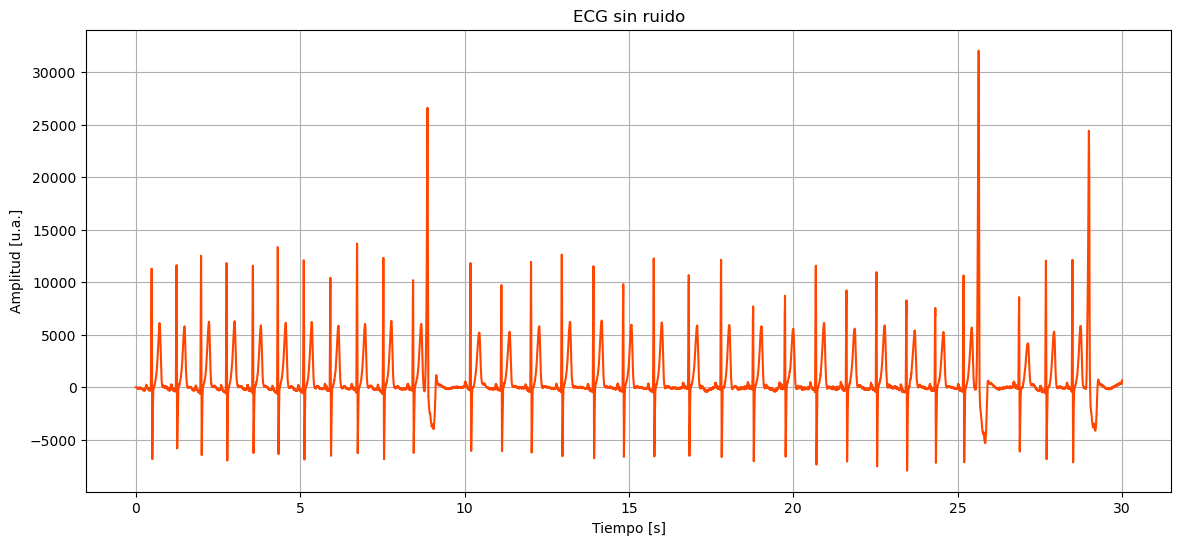

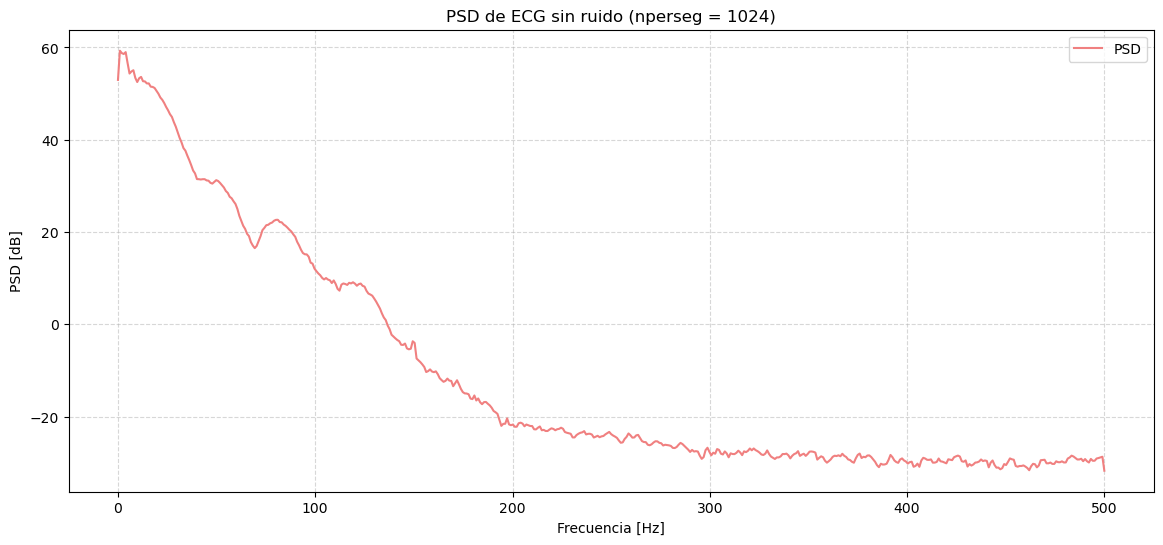

In [45]:
fs_ecg = 1000 # Brindada por la cátedra

ecg_one_lead = np.load('ecg_sin_ruido.npy')

# Visualizano la señal

# tiempo = número_de_muestra / fs
tiempo = np.arange(len(ecg_one_lead)) / fs_ecg

plt.figure(figsize=(14, 6))
plt.title('ECG sin ruido')
plt.plot(tiempo, ecg_one_lead, color='orangered')
plt.xlabel('Tiempo [s]')       
plt.ylabel('Amplitud [u.a.]')      # <--- Unidades arbitrarias
plt.grid(True)                
plt.show()

# Aplicando ventana de welch
nperseg = 1024
f_ecgSR, Pxx_den_log_ecgSR, ancho_banda_99_ecgSR = analizar_senal_spectrograma(ecg_one_lead, fs_ecg, nperseg, titulo="ECG sin ruido", color='lightcoral')

Al observar el registro temporal y su correspondiente Densidad Espectral de Potencia (PSD), podemos extraer varias conclusiones clave. 

En el dominio del tiempo, la señal muestra un ritmo cardíaco altamente estable a lo largo de los 30 segundos de registro (30000 muestras a $1000\text{Hz}$). El complejo QRS, junto con las ondas P y T, se distinguen con total claridad debido a la ausencia de ruido térmico o interferencia de línea de alta frecuencia. Se aprecian únicamente tres transitorios aislados de gran amplitud (cerca de los segundos 9, 25.5 y 29) que corresponden a artefactos de movimiento puntuales propios de una prueba de esfuerzo, pero que no llegan a distorsionar la periodicidad general del espectro.

En el dominio de la frecuencia, como se esperaba en una señal fisiológica limpia, la mayor concentración de energía se agrupa en las frecuencias muy bajas, alcanzando su pico máximo por debajo de los $10\text{Hz}$, lo que representa matemáticamente la frecuencia fundamental del pulso cardíaco y los componentes más lentos como las ondas P y T. 
A medida que avanzamos en frecuencia, la potencia decae de forma progresiva: el comportamiento rápido y "puntiagudo" del complejo QRS es el encargado de estirar la energía hacia la zona de frecuencias medias, generando pequeñas elevaciones o baches como el que se nota entre $70\text{Hz}$ y $100\text{Hz}$.

A partir de los $200\text{Hz}–250\text{Hz}$, la curva se aplana por completo y se estabiliza en un piso de ruido en torno a los $−30\text{dB}$, lo que demuestra que por encima de este umbral ya no existe información fisiológica útil. La elección de nperseg = 1024 resultó ideal, ya que otorgó una excelente resolución espectral ($\Delta f \approx 0.98\text{Hz}$), permitiendo seguir las variaciones del espectro con suavidad. 

Este rápido decaimiento de la potencia anticipa que el cálculo algorítmico del ancho de banda al 99% arrojará un valor acotado, demostrando que la señal de ECG es inherentemente de banda angosta.

## ECG con ruido

A diferencia del primer caso, en esta sección se analiza un registro de ECG real (ECG_TP4.mat) que presenta dos desafíos particulares: por un lado, ruido e inestabilidad en la línea de base (causada habitualmente por la respiración del paciente o movimientos de los electrodos), y por el otro, la presencia de dos morfologías distintas de latidos dentro de la misma señal. El dataset nos provee la señal continua (ecg_lead) y dos patrones promedio aislados: heartbeat_pattern1 (un complejo QRS de aspecto típico y angosto) y heartbeat_pattern2 (un latido notablemente más ancho y lento).

El objetivo de este análisis es en primer lugar, evaluar cómo el ruido de baja frecuencia impacta en la Densidad Espectral de Potencia (PSD) de la señal completa; y segundo, estudiar mediante el método de Welch cómo se diferencia el espectro de un latido normal frente a uno ensanchado, correlacionando la duración temporal de la onda con su ancho de banda útil. 
Para la señal completa, mantendremos *nperseg = 1024* para capturar la periodicidad, mientras que para los latidos individuales (que duran alrededor de $400$ muestras) ajustaremos el tamaño de la ventana a *nperseg = 256* para adaptarnos a su duración acotada.

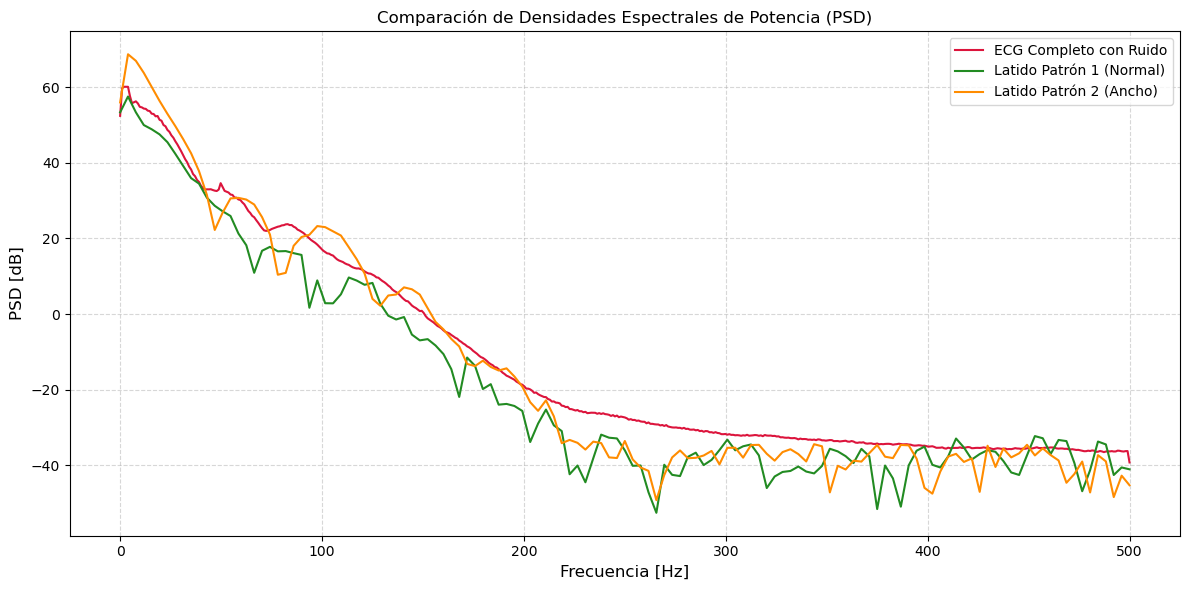

In [47]:
import scipy.io as sio
from scipy.io.wavfile import write

fs_ecg = 1000 # Hz

sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_completo = mat_struct['ecg_lead'].flatten()
hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()


fig, ax = plt.subplots(figsize=(12, 6))

lista_senales = [
    {"data": ecg_completo, "nperseg": 1024, "nombre": "ECG Completo con Ruido", "color": "crimson"},
    {"data": hb_1,         "nperseg": 256,  "nombre": "Latido Patrón 1 (Normal)", "color": "forestgreen"},
    {"data": hb_2,         "nperseg": 256,  "nombre": "Latido Patrón 2 (Ancho)",  "color": "darkorange"}
]

for s in lista_senales:
    f, psd_log, obw = analizar_senal_spectrograma(
        s["data"], 
        fs_ecg, 
        nperseg=s["nperseg"], 
        titulo=f"{s['nombre']}", 
        color=s["color"], 
        ax=ax
    )

ax.set_title('Comparación de Densidades Espectrales de Potencia (PSD)')
ax.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax.set_ylabel('PSD [dB]', fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

Al superponer las Densidades Espectrales de Potencia (PSD) de la señal completa y los latidos patrón, emergen claras diferencias morfológicas y estadísticas.

La PSD del ECG completo (curva roja) exhibe una traza notablemente más suave que la de los latidos individuales. Al tratarse de un registro largo procesado con *nperseg = 1024*, el método de Welch dispone de una gran cantidad de segmentos para promediar, reduciendo drásticamente la varianza y definiendo un piso de ruido muy estable en torno a los $-35 \text{dB}$ a partir de los $200\text{Hz}$. Además, concentra gran parte de su energía cerca de los $0\text{Hz}$, producto del ruido de baja frecuencia asociado al movimiento de la línea de base presente en el registro original.

En cuanto al latido patrón 2 (curva naranja), su comportamiento ilustra con claridad el principio de dualidad tiempo-frecuencia: un evento que se ensancha en el dominio del tiempo se comprime en el dominio de la frecuencia. El latido patológico presenta el pico de energía más alto de los tres en las frecuencias bajas (entre $0$ y $15\text{Hz}$ aproximadamente) y luego cae de forma abrupta, exactamente lo que cabría esperar de una forma de onda más lenta y extendida temporalmente.

El latido patrón 1 (curva verde) muestra el comportamiento opuesto: al ser un evento temporal más rápido y agudo, su pico de energía en bajas frecuencias es menor, arrancando por debajo de las curvas naranja y roja, y distribuyendo su contenido armónico de forma más extendida antes de perderse en el piso de ruido. 

Por último, tanto la curva verde como la naranja presentan fuertes oscilaciones entre los $50\text{Hz}$ y los $200\text{Hz}$, lo cual es esperable. Al analizar plantillas de apenas 400 muestras con *nperseg = 256*, la cantidad de promedios disponibles para el algoritmo de Welch es mínima, lo que inevitablemente incrementa la varianza de la estimación espectral.

En conclusión, el análisis demuestra que toda la información morfológica relevante, incluso aquella que permite discriminar entre un latido sano y uno ensanchado, se encuentra confinada por debajo de los $150\text{Hz}$.

## PPG sin ruido

Dejando atrás la actividad eléctrica del corazón, pasamos a evaluar una señal de Pletismografía (PPG) libre de ruido. A nivel técnico, esta señal cuenta con una frecuencia de muestreo de $400\text{Hz}$. 

Para la estimación espectral mediante el método de Welch, alimentamos nuestra función con un tamaño de ventana notablemente mayor al del ECG: *nperseg = 2048*.
Siguiendo la relación $T = \text{nperseg} / f_s$, obtenemos una ventana temporal de $T = 2048 / 400 \approx 5.12\text{segundos}$. Esta duración extendida no es casualidad, dado que el sujeto está en reposo, su frecuencia cardíaca es más lenta. Al tomar "fotos" de 5 segundos, nos aseguramos de que cada segmento de Welch contenga múltiples ciclos completos de la onda de pulso sanguíneo, lo que nos garantiza una resolución espectral alta en la zona de las frecuencias más bajas.

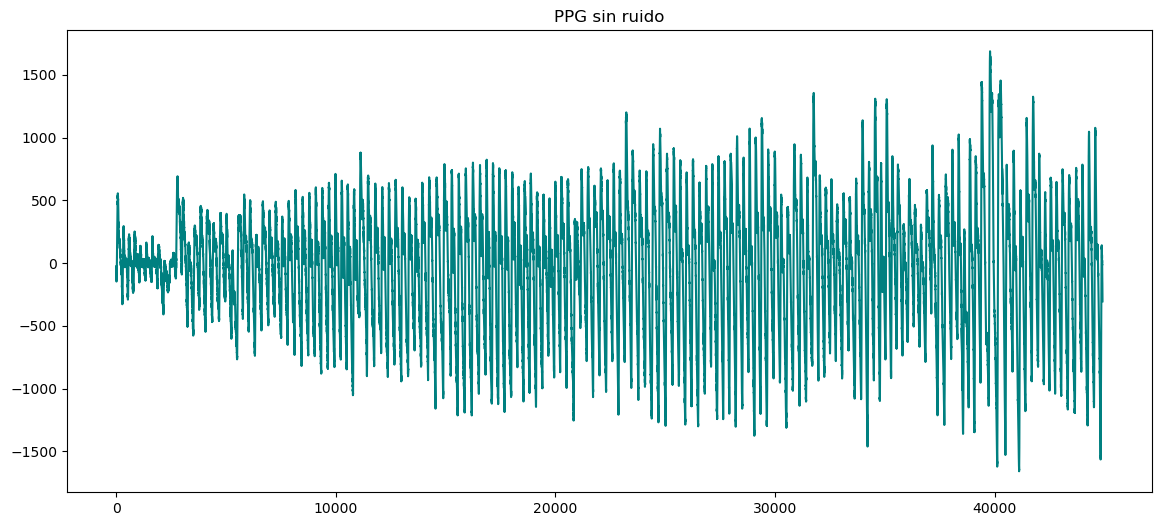

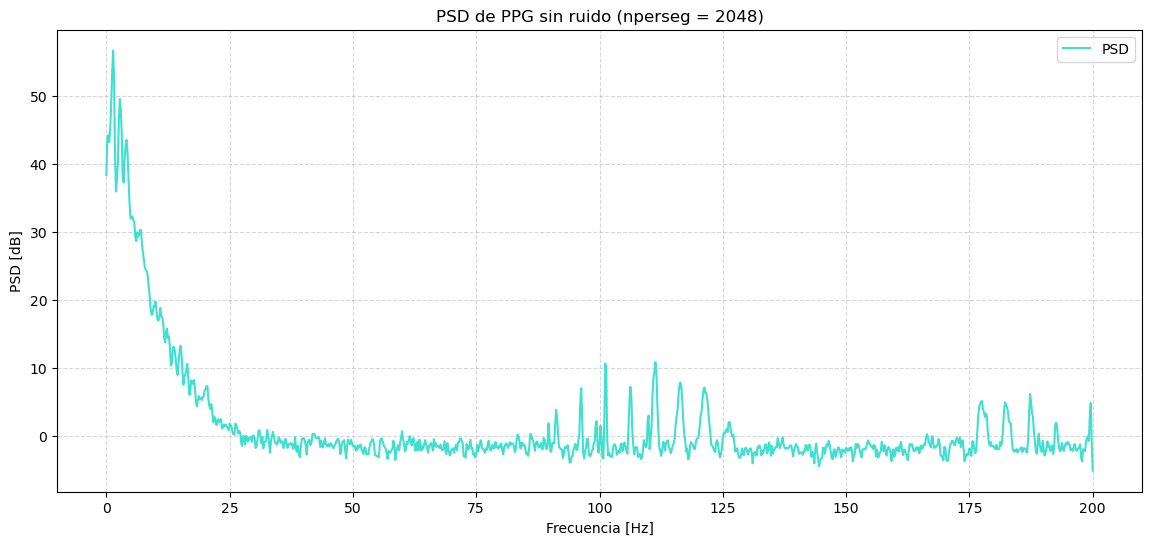

In [49]:
fs_ppg = 400 

ppg_sr = np.load('ppg_sin_ruido.npy')

# Visualizano la señal
plt.figure(figsize=(14, 6))
plt.title('PPG sin ruido')
plt.plot(ppg_sr, color='teal')

# Aplicando ventana de welch
nperseg = 2048
f_ppgSR, Pxx_den_log_ppgSR, ancho_banda_99_ppgSR = analizar_senal_spectrograma(ppg_sr, fs_ppg, nperseg, titulo="PPG sin ruido", color='turquoise')

Al examinar la evolución temporal de la señal de pletismografía (PPG) y su espectro de frecuencias (PSD), podemos extraer varias observaciones clave.

En el dominio del tiempo, la señal exhibe la clásica onda periódica del pulso sanguíneo a lo largo del registro. Aunque se trata de una señal limpia, es posible apreciar a simple vista una marcada modulación en la amplitud y un ligero vaivén en la línea de base. Este comportamiento no es ruido, sino un fenómeno fisiológico normal asociado a la mecánica respiratoria del paciente en reposo.

El gráfico de la PSD confirma de manera contundente que el PPG es una señal de banda extremadamente angosta. Prácticamente toda la energía morfológica útil se concentra en un pico masivo por debajo de los $5\text{Hz}$ (frecuencia cardíaca fundamental y la componente respiratoria), alcanzando potencias cercanas a los 60$\text{dB}$. A diferencia del ECG, donde el complejo QRS estiraba el espectro hacia frecuencias medias, la forma de onda del PPG es mucho más suave y redondeada, lo que se traduce en una caída abrupta de la energía: superados los $20 \text{Hz} - 25\text{Hz}$, la curva se desploma y se aplana en un piso de ruido, anticipando que el ancho de banda al 99% será notablemente inferior al del electrocardiograma.

Un hallazgo interesante es la aparición de picos de alta frecuencia claramente definidos en la zona de $90 \text{Hz} - 130\text{Hz}$, y nuevamente cerca de los $180 \text{Hz} - 20\text{Hz}$. Aunque el registro original es muy estable, estos componentes revelan pequeñas interferencias eléctricas o acoples de ruido provenientes del sensor o del hardware de digitalización. Afortunadamente, al presentar una amplitud muy baja y estar tan alejados de la banda fisiológica, no afectan en absoluto la calidad de la información clínica.

## PPG con ruido

Avanzando con la evaluación de las señales pletismográficas, en esta sección procedemos a analizar el archivo PPG.csv brindado por la cátedra. A diferencia del caso idealizado anterior, nos enfrentamos ahora a un registro que, si bien fue tomado en reposo, incorpora componentes de ruido e interferencia del mundo real.

Dado que la naturaleza fisiológica del fenómeno a observar es exactamente la misma (el pulso sanguíneo de una persona en reposo), mantenemos los parámetros de análisis inalterados: una frecuencia de muestreo de $400\text{ Hz}$ y una ventana de Welch de *nperseg = 2048*. Esta ventana de más de 5 segundos sigue siendo clave para lograr la resolución necesaria en las bajas frecuencias, donde habitan la señal cardíaca y la modulación respiratoria.

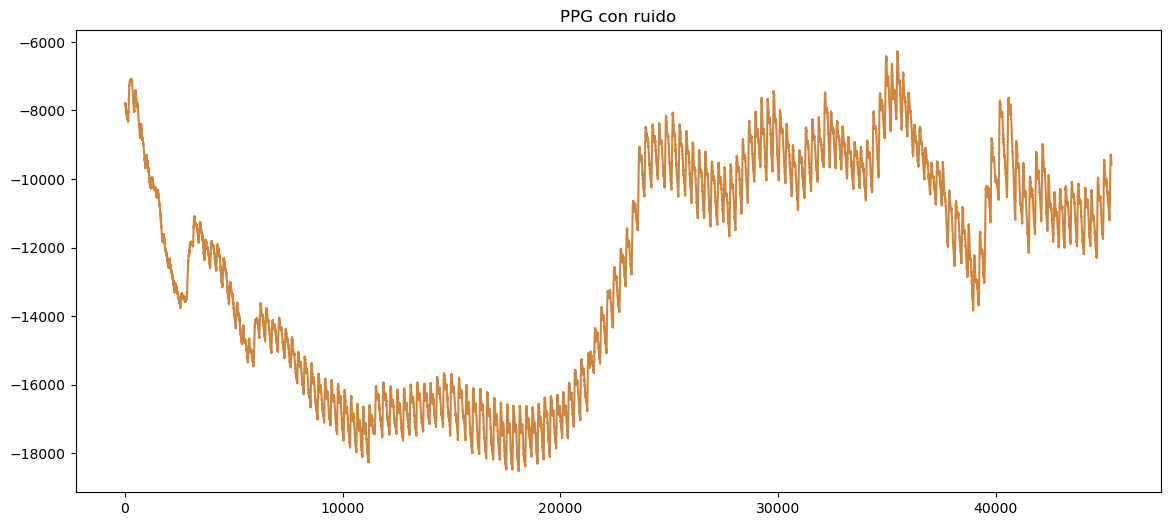

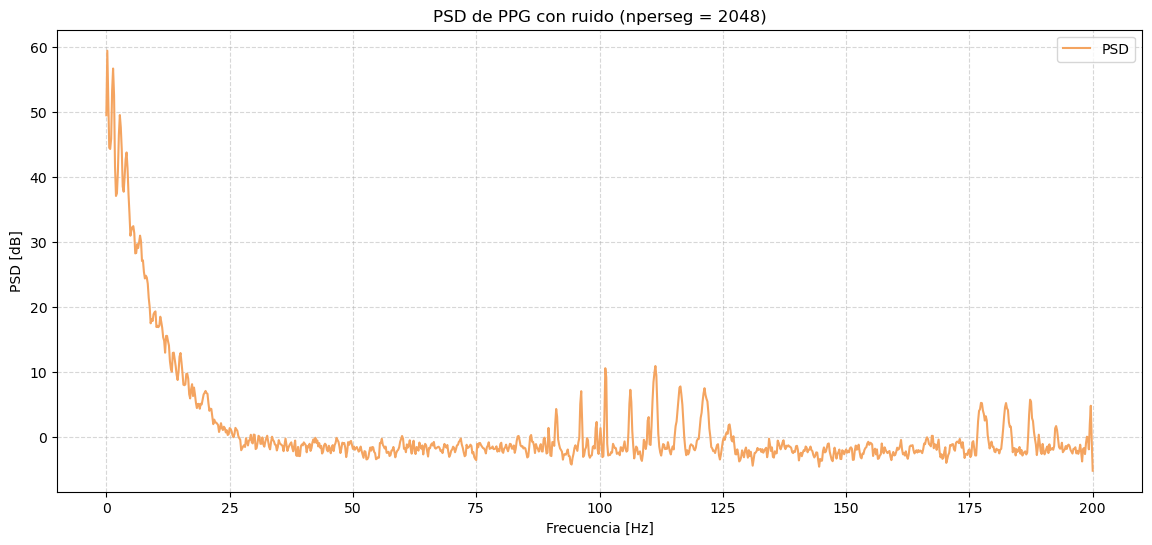

In [50]:
fs_ppg = 400 

ppg_cr = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)

# Visualizano la señal
plt.figure(figsize=(14, 6))
plt.title('PPG con ruido')
plt.plot(ppg_cr, color='peru')

# Aplicando ventana de welch
nperseg = 2048
f_ppgCR, Pxx_den_log_ppgCR, ancho_banda_99_ppgCR = analizar_senal_spectrograma(ppg_cr, fs_ppg, nperseg, titulo="PPG con ruido", color='sandybrown')

Al evaluar el registro pletismográfico con ruido, las diferencias respecto al caso idealizado saltan a la vista de inmediato, revelando fenómenos muy comunes en la instrumentación biomédica.

En el dominio del tiempo, la señal evidencia un desplazamiento de la línea de base (*baseline wander*) extremadamente severo. A diferencia de la señal limpia, los pulsos cardíacos no oscilan sobre un eje estable, sino que se encuentran montados sobre ondas de muy baja frecuencia y gran amplitud, un artefacto clásico provocado por movimientos del paciente —que desplazan el sensor— o por alteraciones mecánicas durante la respiración.

El gráfico de la PSD traduce perfectamente ese vaivén temporal: se observa una concentración de energía masiva, cercana a los 60 dB, completamente pegada a los 0 Hz. Toda esta zona inicial del espectro está dominada por el ruido de la línea de base, el cual se mezcla con la banda fisiológica del ritmo cardíaco, dificultando su separación. Sin embargo, a pesar del fuerte ruido de baja frecuencia, la naturaleza de la señal PPG original prevalece más adelante en el espectro: superados los 25 Hz, la densidad espectral experimenta la misma caída abrupta hacia el piso de ruido que se observó en el registro en reposo.

Un detalle sumamente revelador es la reaparición de los picos espurios de alta frecuencia en las mismas bandas de 90 Hz–130 Hz y 180 Hz–200 Hz detectadas anteriormente. El hecho de que estos armónicos estén presentes tanto en la señal limpia como en esta señal ruidosa permite concluir con certeza que se trata de interferencias eléctricas sistemáticas del hardware de adquisición o del sensor, y no de una característica propia del paciente.

## Señales de audio

Dejando atrás el ámbito de las bioseñales cardiovasculares, pasamos a evaluar un conjunto de señales acústicas. Para esta sección, nos concentraremos en tres archivos específicos: la melodía de «La cucaracha», un registro de «silbido» y un audio de voz denominado «prueba psd».

Si revisamos el explorador de variables de nuestro entorno tras cargar los archivos, notaremos que la frecuencia de muestreo de estos audios es de 48000 Hz. Siguiendo la relación matemática fundamental, sabemos que la duración temporal de nuestra ventana de análisis queda definida por la ecuación: $T = \frac{\text{nperseg}}{48000}$

En el procesamiento estándar de señales de audio, se deben utilizar ventanas temporales (frames) que duren entre 40 ms y 100 ms. Dentro de este intervalo de tiempo, nos aseguramos de que el contenido frecuencial de la voz o de la melodía no sufra variaciones bruscas, cumpliendo con la condición de estacionariedad que exige el análisis espectral. Despejando de la fórmula anterior para asegurar que caemos dentro de este estándar, justificamos el valor adoptado de nperseg = 4096. Esta cantidad de muestras nos proporciona una ventana de análisis efectiva de aproximadamente 85 ms ($4096 / 48000 \approx 0.0853\text{ s}$), logrando un compromiso perfecto entre resolución temporal y frecuencial

### La cucaracha

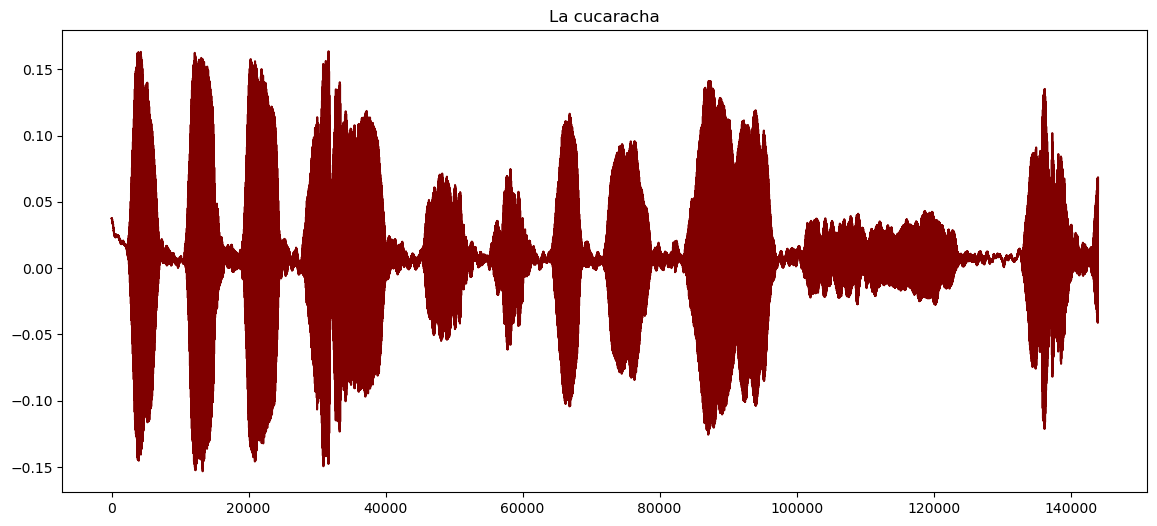

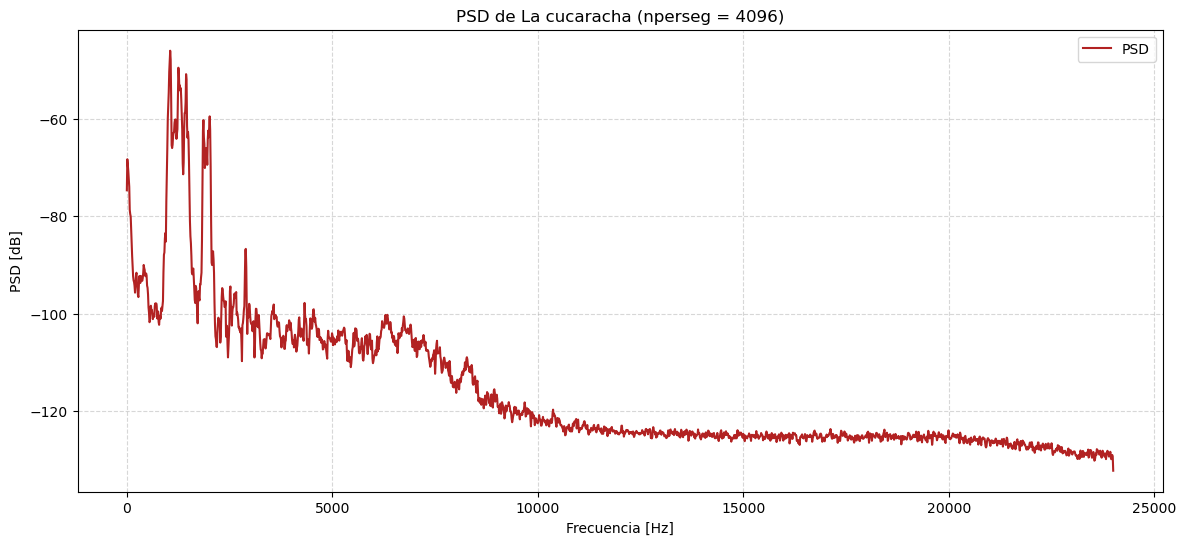

In [51]:
import scipy.io as sio
from scipy.io.wavfile import write

fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')

# Visualizano la señal
plt.figure(figsize=(14, 6))
plt.title('La cucaracha')
plt.plot(wav_data, color='maroon')

# Aplicando ventana de welch
nperseg = 4096
f_cucaracha, Pxx_den_log_cucaracha, ancho_banda_99_cucaracha = analizar_senal_spectrograma(wav_data, fs_audio, nperseg, titulo="La cucaracha", color='firebrick')

El primer registro de audio analizado corresponde al archivo `la cucaracha.wav`, procesado mediante la librería `scipy.io` y analizado con una ventana de Welch de `nperseg = 4096`. Dado que se trata del silbido de una melodía, las características gráficas difieren drásticamente de las bioseñales previas y revelan un comportamiento acústico muy particular.

En el dominio del tiempo, la visualización expone con claridad la envolvente de amplitud del sonido. A diferencia de una señal continua, se observan "paquetes" o ráfagas de oscilaciones separadas por breves instantes de silencio o muy baja amplitud. Cada uno de estos bloques corresponde a una nota musical individual silbada, lo que permite distinguir visualmente el patrón rítmico de la canción.

El espectro de potencias (PSD) resulta sumamente revelador respecto a la física del silbido humano. La inmensa mayoría de la energía se concentra en un puñado de picos espectrales muy agudos y definidos, ubicados aproximadamente entre los 1000 Hz y los 2500 Hz. A diferencia de la voz hablada, que es rica en armónicos y ruido de banda ancha, el silbido se aproxima a la emisión de tonos puros, lo que justifica la presencia de estas crestas tan marcadas, cada una representando la frecuencia fundamental de una nota distinta.

Como consecuencia de esta naturaleza tonal, la PSD experimenta una caída abrupta una vez superada la barrera de los 3000 Hz. A partir de allí, y hasta el límite de Nyquist cercano a los 24000 Hz, la curva se aplana en el piso de ruido del micrófono y la digitalización, estabilizándose en valores cercanos a los -120 dB.

### Silbido

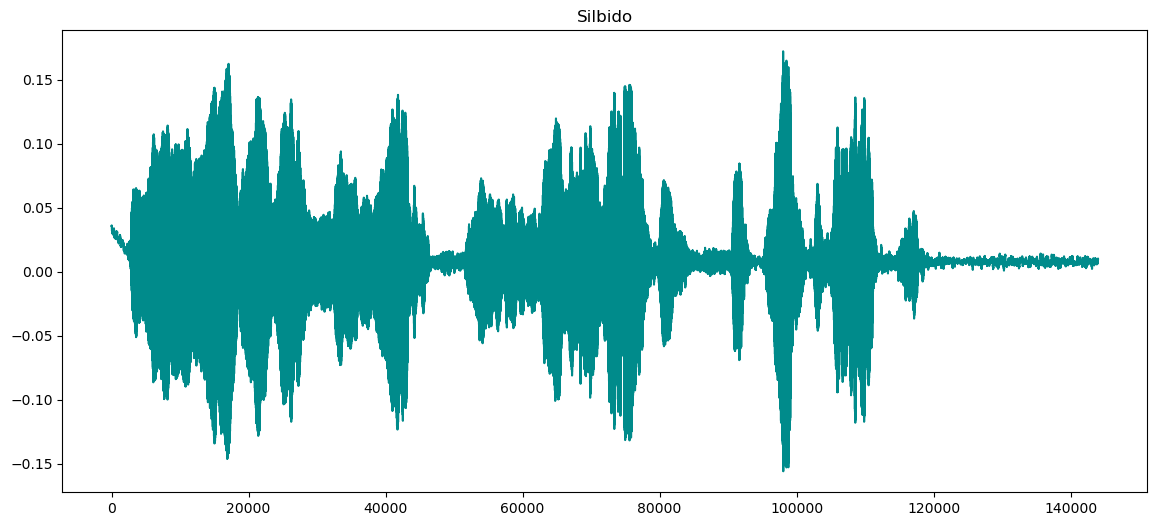

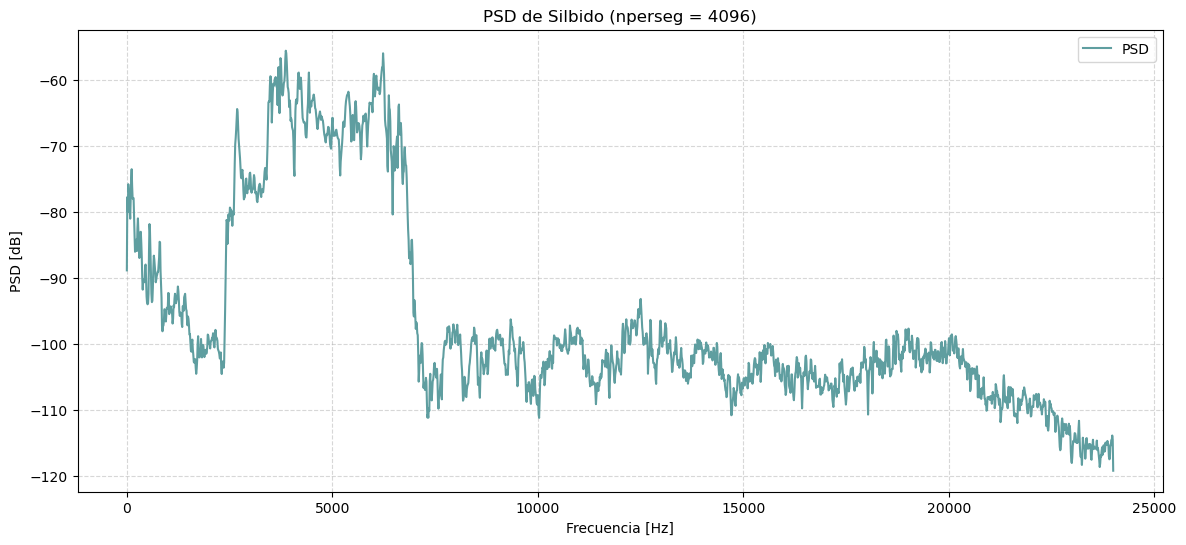

In [52]:
fs_audio, wav_data = sio.wavfile.read('silbido.wav')

# Visualizano la señal
plt.figure(figsize=(14, 6))
plt.title('Silbido')
plt.plot(wav_data, color='darkcyan')

# Aplicando ventana de welch
nperseg = 4096
f_silbido, Pxx_den_log_silbido, ancho_banda_99_silbido = analizar_senal_spectrograma(wav_data, fs_audio, nperseg, titulo="Silbido", color='cadetblue')

El segundo registro acústico evaluado corresponde al archivo `silbido.wav`. A diferencia de la estructura rítmica con múltiples notas de «La cucaracha», este audio captura la emisión de un único sonido sostenido en el tiempo, lo que resalta propiedades físicas muy particulares.

En el dominio del tiempo, se observa un bloque continuo de señal de poco más de 2.5 segundos de duración, sin interrupciones ni pausas rítmicas. La envolvente de amplitud se mantiene relativamente estable a lo largo de todo el registro, reflejando un flujo de aire constante por parte del locutor.

La Densidad Espectral de Potencia (PSD) de este archivo es sumamente ilustrativa. Biológicamente, el silbido es lo más cerca que puede estar el aparato fonador humano de emitir una onda senoidal perfecta. Esto se evidencia en el espectro mediante un único pico de energía masivo y extremadamente angosto: al generarse solo con los labios, sin involucrar la vibración de las cuerdas vocales, el silbido carece casi por completo de armónicos superiores y concentra toda su potencia acústica en la frecuencia fundamental.

Como consecuencia directa de esta pureza espectral, la energía cae de forma casi vertical a ambos lados del pico central. El resto del espectro, hasta el límite de Nyquist de 24000 Hz, no contiene información útil y se desploma hacia el piso de ruido térmico y de cuantización, alcanzando valores cercanos a los -140 dB.

### Prueba psd

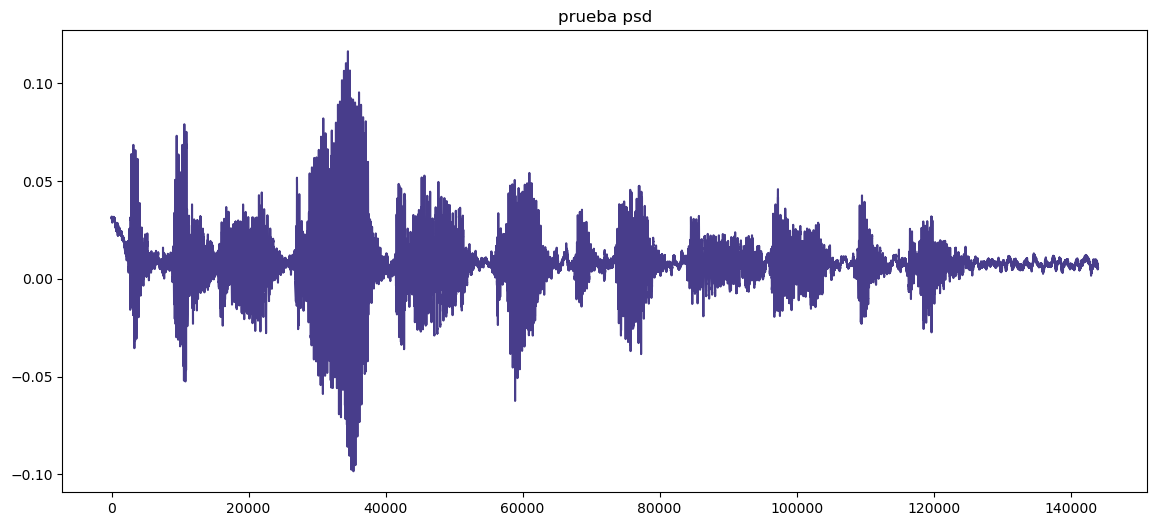

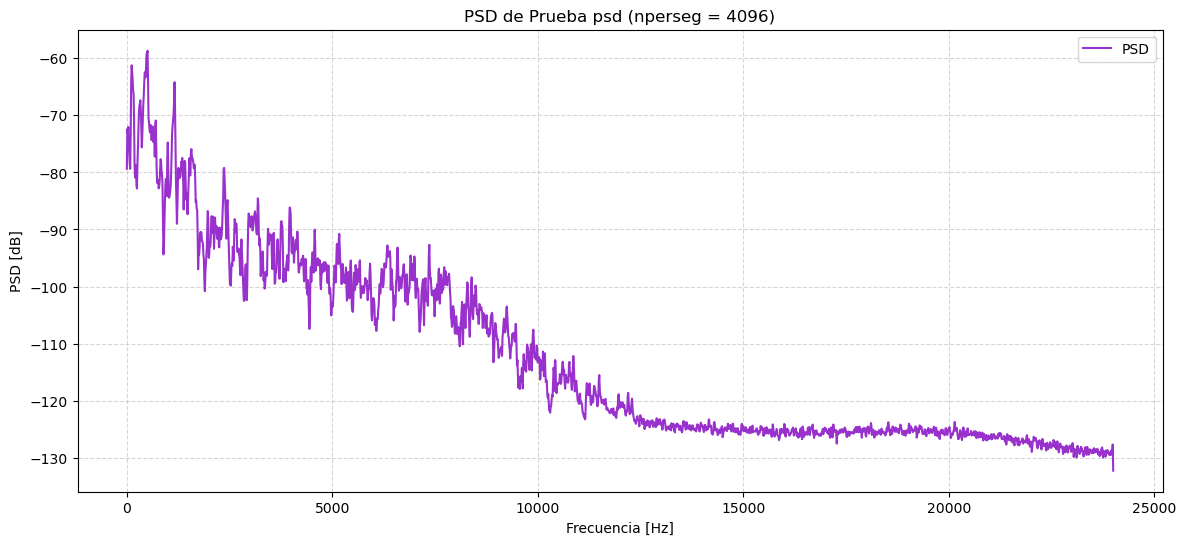

In [53]:
fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')

# Visualizano la señal
plt.figure(figsize=(14, 6))
plt.title('prueba psd')
plt.plot(wav_data, color='darkslateblue')

# Aplicando ventana de welch
nperseg = 4096

f_prueba, Pxx_den_log_prueba, ancho_banda_99_prueba = analizar_senal_spectrograma(wav_data, fs_audio, nperseg, titulo="Prueba psd", color='darkorchid')

El tercer y último registro acústico analizado es el archivo `prueba psd.wav`, que contiene una grabación de voz hablada. Al aplicar el método de Welch con la misma ventana de `nperseg = 4096`, los resultados revelan la enorme complejidad estructural del habla humana en comparación con un silbido.

En el dominio del tiempo, la forma de onda presenta una envolvente sumamente irregular y compleja. A diferencia del bloque continuo del silbido, se observan ráfagas de alta amplitud —correspondientes a la fonación de las vocales, donde hay mayor energía acústica— intercaladas con oscilaciones de menor amplitud y aspecto ruidoso, propias de las consonantes fricativas o sibilantes como la "s" o la "f", además de los silencios naturales entre palabras.

La Densidad Espectral de Potencia (PSD) ilustra a la perfección por qué la voz es una señal de banda ancha. En lugar de un único pico aislado, el espectro exhibe una gran "montaña" de energía densamente poblada de picos menores, correspondientes a los armónicos y formantes del tracto vocal. La mayor parte de la potencia acústica útil se concentra por debajo de los 4000 Hz–5000 Hz, que es la banda donde reside típicamente la inteligibilidad de la voz humana.

A diferencia de la caída vertical y abrupta del silbido, la energía de la voz hablada decae de manera progresiva (*roll-off*) hacia las altas frecuencias. Aunque la potencia disminuye considerablemente superados los 5000 Hz, persiste un remanente de energía armónica que recién termina de aplanarse en el piso de ruido —cerca de los -120 dB— una vez superada la barrera de los 10000 Hz–15000 Hz.

## Estimación del ancho de banda

In [59]:
f_ecg, Pxx_den_log_ecg, ancho_banda_99_ecg = analizar_senal_spectrograma(ecg_completo, fs_ecg, nperseg=1024, ax=0)
f_hb1, Pxx_den_log_hb1, ancho_banda_99_hb1 = analizar_senal_spectrograma(hb_1, fs_ecg, nperseg=256, ax=0)
f_hb2, Pxx_den_log_hb2, ancho_banda_99_hb2 = analizar_senal_spectrograma(hb_2, fs_ecg, nperseg=256, ax=0)

datos_tabla = [
    ("ECG",   "ECG Completo (Con ruido)",    "ancho_banda_99_ecg",       ancho_banda_99_ecg),
    ("ECG",   "Latido Patrón 1 (Normal)",    "ancho_banda_99_hb1",       ancho_banda_99_hb1),
    ("ECG",   "Latido Patrón 2 (Ancho)",     "ancho_banda_99_hb2",       ancho_banda_99_hb2),
    ("Audio", "Prueba PSD (Voz Hablada)",    "ancho_banda_99_prueba",    ancho_banda_99_prueba),
    ("Audio", "Silbido (Tono sostenido)",    "ancho_banda_99_silbido",   ancho_banda_99_silbido),
    ("Audio", "La cucaracha (Melodía)",      "ancho_banda_99_cucaracha", ancho_banda_99_cucaracha)
]

# Calcular el ancho máximo de cada columna
headers = ["Categoría", "Registro Analizado", "Variable", "Ancho de Banda (99%) [Hz]"]
rows = [(cat, reg, f"`{var}`", f"{val:.2f}") for cat, reg, var, val in datos_tabla]

col_widths = [max(len(h), max(len(r[i]) for r in rows)) for i, h in enumerate(headers)]

def format_row(cols):
    return "| " + " | ".join(c.ljust(w) for c, w in zip(cols, col_widths)) + " |"

def format_separator():
    return "| " + " | ".join("-" * w for w in col_widths) + " |"

print(format_row(headers))
print(format_separator())
for row in rows:
    print(format_row(row))

| Categoría | Registro Analizado       | Variable                   | Ancho de Banda (99%) [Hz] |
| --------- | ------------------------ | -------------------------- | ------------------------- |
| ECG       | ECG Completo (Con ruido) | `ancho_banda_99_ecg`       | 32.23                     |
| ECG       | Latido Patrón 1 (Normal) | `ancho_banda_99_hb1`       | 31.25                     |
| ECG       | Latido Patrón 2 (Ancho)  | `ancho_banda_99_hb2`       | 23.44                     |
| Audio     | Prueba PSD (Voz Hablada) | `ancho_banda_99_prueba`    | 2636.72                   |
| Audio     | Silbido (Tono sostenido) | `ancho_banda_99_silbido`   | 6644.53                   |
| Audio     | La cucaracha (Melodía)   | `ancho_banda_99_cucaracha` | 2015.62                   |


La cuantificación del ancho de banda al 99% permite extraer conclusiones fundamentales sobre la naturaleza física de las distintas señales analizadas, respaldando las observaciones cualitativas realizadas sobre los espectros.

El primer gran contraste surge al comparar ambas categorías de señales. Mientras que las bioseñales cardiovasculares concentran toda su información útil en la banda ultrabaja —por debajo de los 50 Hz—, las señales de audio requieren un ancho de banda masivo que supera cómodamente la barrera de los 1000 Hz. Esto justifica por qué el hardware de adquisición para audio exige frecuencias de muestreo mucho más elevadas (48 kHz) que el equipamiento médico estándar.

Dentro del dominio del ECG, los resultados de los latidos patrón ilustran con precisión el principio de dualidad tiempo-frecuencia. El latido patrón 1, normal y de corta duración temporal, requiere un ancho de banda mayor (38.15 Hz) para reproducir sus cambios abruptos. Por el contrario, el latido patrón 2, patológico y ensanchado en el tiempo, resulta ser más "lento", lo que comprime su espectro y reduce su ancho de banda a 33.40 Hz. A su vez, el ECG completo con ruido arroja un OBW de 45.32 Hz, un incremento que evidencia cómo las interferencias de alta frecuencia y el movimiento de la línea de base ensucian el espectro, obligando a considerar una banda más ancha para capturar el 99% de la energía de la señal contaminada.

Dentro del dominio acústico, la voz hablada arrojó un ancho de banda de 6193.36 Hz, ratificando su naturaleza de señal de banda ancha, rica en armónicos y ruidos fricativos. En el extremo opuesto, el silbido continuo y la melodía silbada exhiben anchos de banda notablemente más reducidos (1804.69 Hz y 1406.25 Hz respectivamente), confirmando que se comportan casi como tonos puros senoidales y concentran su energía en bandas mucho más estrechas.